In [2]:
import numpy as np
import pandas as pd
import pyarrow as pa
import fastparquet as fp
import os
import matplotlib.pyplot as plt
import seaborn as sns

### Analiza a porcentagem de missing

In [3]:
ARQUIVO_PARQUET = "dados/cnpqBolsasAuxilios.parquet"
df = pd.read_parquet(ARQUIVO_PARQUET)

print(f'O conjunto de dados possui {df.shape[0]} linhas e {df.shape[1]} colunas.')

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Valores Ausentes': missing_values,
    'Porcentagem (%)': missing_percentage
})

missing_info = missing_info[missing_info['Valores Ausentes'] > 0].sort_values(by='Porcentagem (%)', ascending=False)

print('\nValores ausentes por coluna (e suas porcentagens):')
print(missing_info.to_string())


O conjunto de dados possui 3274778 linhas e 21 colunas.

Valores ausentes por coluna (e suas porcentagens):
                           Valores Ausentes  Porcentagem (%)
palavra_chave                       2849752        87.021227
titulo_do_projeto                   2567532        78.403238
regiao_destino                      2207053        67.395500
sigla_uf_origem                      242197         7.395830
instituicao_origem                   212561         6.490852
sigla_uf_destino                      99162         3.028053
cidade_destino                        15165         0.463085
sigla_instituicao_destino             12551         0.383263
sigla_instituicao_macro               12380         0.378041
instituicao_destino                   12291         0.375323
area                                   9092         0.277637
valor_pago                              564         0.017223
ano_referencia                            1         0.000031


### histograma do fomento -> 'valor pago'

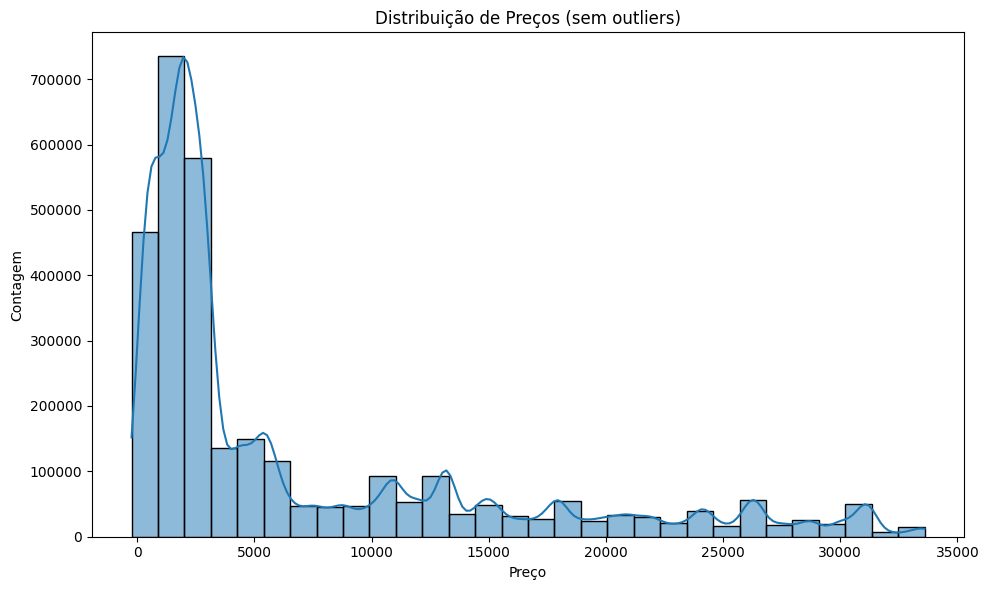

In [13]:

q = df['valor_pago'].quantile(0.95)
filtered_prices = df[df['valor_pago'] <= q]['valor_pago']

plt.figure(figsize=(10, 6))
sns.histplot(filtered_prices, bins=30, kde=True)

plt.title('Distribuição de Preços (sem outliers)')
plt.xlabel('Preço')
plt.ylabel('Contagem')

plt.tight_layout()
plt.show()
